In [1]:
!pip install jsonlines
!pip install seaborn

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Data Load

Data is stored in google drive

In [3]:
from pathlib import Path
DATA_FOLDER = Path('/content/drive/MyDrive/DSCI599/data')

## Load data

In [41]:
import ipaddress
import datetime
import pandas as pd
import numpy as np


#  glob all files ending with strategy
# hourly_files = DATA_FOLDER.glob("*.strategy")

#  (the extension CAIDA use for hourly files)
#  only use May 25th 2016, 11PM (GMT)
hourly_files = [DATA_FOLDER / "1464217200.strategy"]

hourly_columns = [
    "source_ip",
    "num_scanned_destination_ips",
    "num_unique_flows",
    "num_packets",
    "timestamp_first_activity",
    "timestamp_last_activity",
    "same_packet_size_flag",
    "avg_packet_size",
    "num_unique_Bs_scanned",
    "num_unique_Cs_scanned",
    "num_unique_Ds_scanned",
    "num_scanned_24_blocks",
    "num_non_conficker_destinations",
    "ip_address_range_diff",
    "destination_port",
    "protocol"
]

# read the dataset as a pandas dataframe
hourly_df = []
hourly_timestamps = []
for f in hourly_files:
  df = pd.read_csv(f, sep='|', header=None, names=hourly_columns)

  timestamp = int(f.stem)
  dt = str(datetime.datetime.fromtimestamp(timestamp))
  df.name = dt
  hourly_df.append(df)
  hourly_timestamps.append(dt)

def process_df(df: pd.DataFrame) -> pd.DataFrame:
  """
  preprocess df function for reprocudibility
  """

  drop_columns = [
    "timestamp_first_activity",
    "timestamp_last_activity",
    "ip_address_range_diff"
    ]

  # ip set to int and set ip as index
  df['int_source_ip'] = df['source_ip'].map(lambda ip: int(ipaddress.ip_address(ip)))
  df = df.drop(columns = ['source_ip'])

  # get activity time
  df['time_activity'] = df['timestamp_last_activity'] - df['timestamp_first_activity']

  # get ips scanned rate
  # set to -1 if time activity is 0
  df['ip_scanned_rate'] = np.where(
    df['time_activity'] == 0,
    -1,
    df['num_scanned_destination_ips'] / df['time_activity']
    )

  """
  To avoid for graph construction later,
  aggregate all (source_ip -> protocol -> destination)
  so there's only one edge per (source_ip -> protocol -> destination)
  """
  df = df.groupby(["int_source_ip", "destination_port", "protocol"]).mean().reset_index()

  # drop rows that have only scanned less than 10 destination ips
  # similar to paper [2] in Project B
  df = df[df['num_scanned_destination_ips'] > 10]
  df = df.drop(columns = drop_columns)
  return df

for i in range(len(hourly_df)):
  df = hourly_df[i].copy()
  df = process_df(df)

  hourly_df[i] = df

In [42]:
hourly_df[0].head()

,int_source_ip,destination_port,protocol,num_scanned_destination_ips,num_unique_flows,num_packets,same_packet_size_flag,avg_packet_size,num_unique_Bs_scanned,num_unique_Cs_scanned,num_unique_Ds_scanned,num_scanned_24_blocks,num_non_conficker_destinations,time_activity,ip_scanned_rate
0,16968188,23,6,316.0,316.0,945.0,1.0,60.0,175.0,182.0,177.0,316.0,65.0,3540.0,0.089266
1,17372742,445,6,661.0,661.0,1322.0,1.0,48.0,125.0,234.0,126.0,654.0,661.0,3540.0,0.186723
2,17384594,445,6,169.0,169.0,329.0,1.0,48.0,98.0,117.0,89.0,169.0,169.0,3360.0,0.050298
3,17400985,23,6,256.0,256.0,762.0,1.0,60.0,1.0,1.0,256.0,1.0,128.0,0.0,-1.000000
4,17401572,445,6,571.0,571.0,1142.0,1.0,48.0,124.0,232.0,125.0,564.0,571.0,3540.0,0.161299


In [43]:
hourly_df[0].shape

(132956, 15)

# Explanatory Data Analysis

In [44]:
df = hourly_df[0]
df.columns

Index(['int_source_ip', 'destination_port', 'protocol',
       'num_scanned_destination_ips', 'num_unique_flows', 'num_packets',
       'same_packet_size_flag', 'avg_packet_size', 'num_unique_Bs_scanned',
       'num_unique_Cs_scanned', 'num_unique_Ds_scanned',
       'num_scanned_24_blocks', 'num_non_conficker_destinations',
       'time_activity', 'ip_scanned_rate'],
      dtype='object')

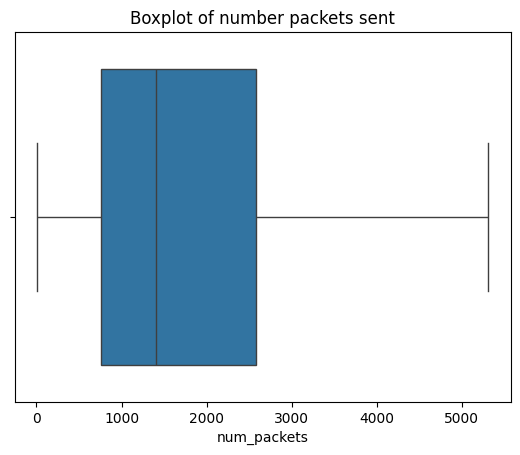

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(df,
            x='num_packets',
            showfliers=False)
plt.title('Boxplot of number packets sent')
plt.show()

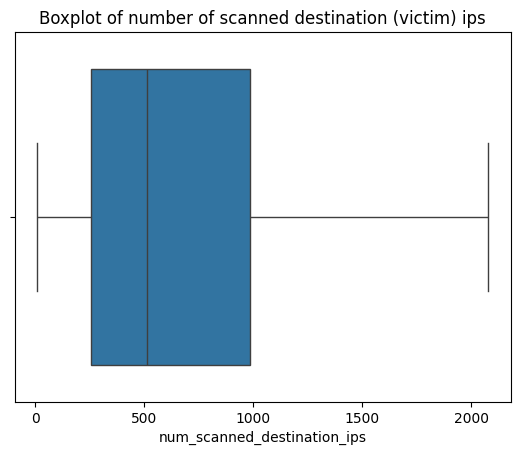

In [46]:
sns.boxplot(df,
            x='num_scanned_destination_ips',
            showfliers=False)
plt.title('Boxplot of number of scanned destination (victim) ips')
plt.show()

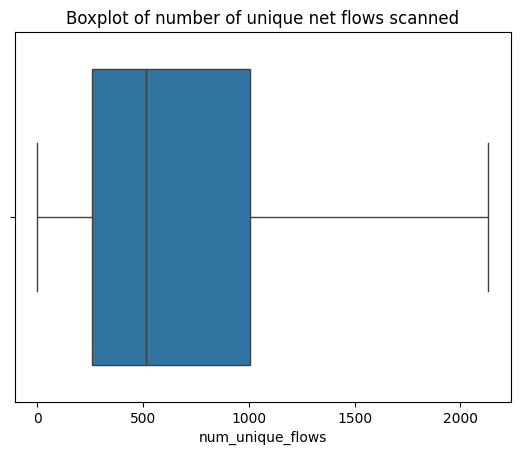

In [47]:
sns.boxplot(df,
            x='num_unique_flows',
            showfliers=False)

plt.title('Boxplot of number of unique net flows scanned')

plt.show()

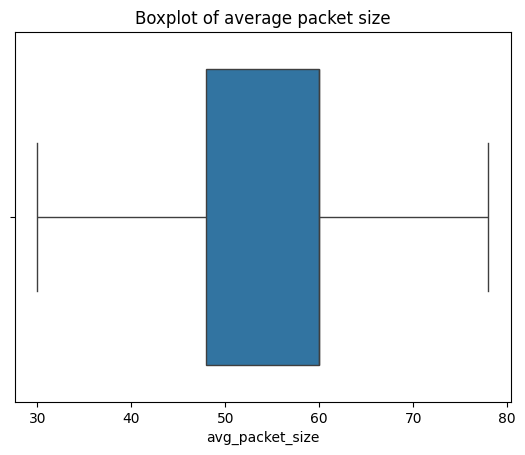

In [48]:
sns.boxplot(df,
            x='avg_packet_size',
            showfliers=False)

plt.title('Boxplot of average packet size')

plt.show()

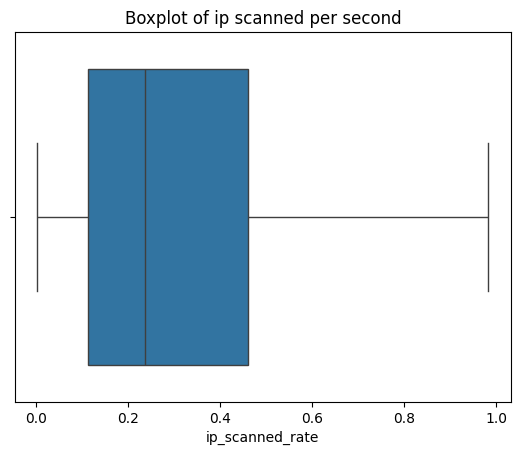

In [49]:
sns.boxplot(df,
            x = "ip_scanned_rate",
            showfliers=False)
plt.title("Boxplot of ip scanned per second")
plt.show()

## Correlation plot

Multi-collinearity is pretty bad for ML and DL as well

> https://seaborn.pydata.org/examples/many_pairwise_correlations.html

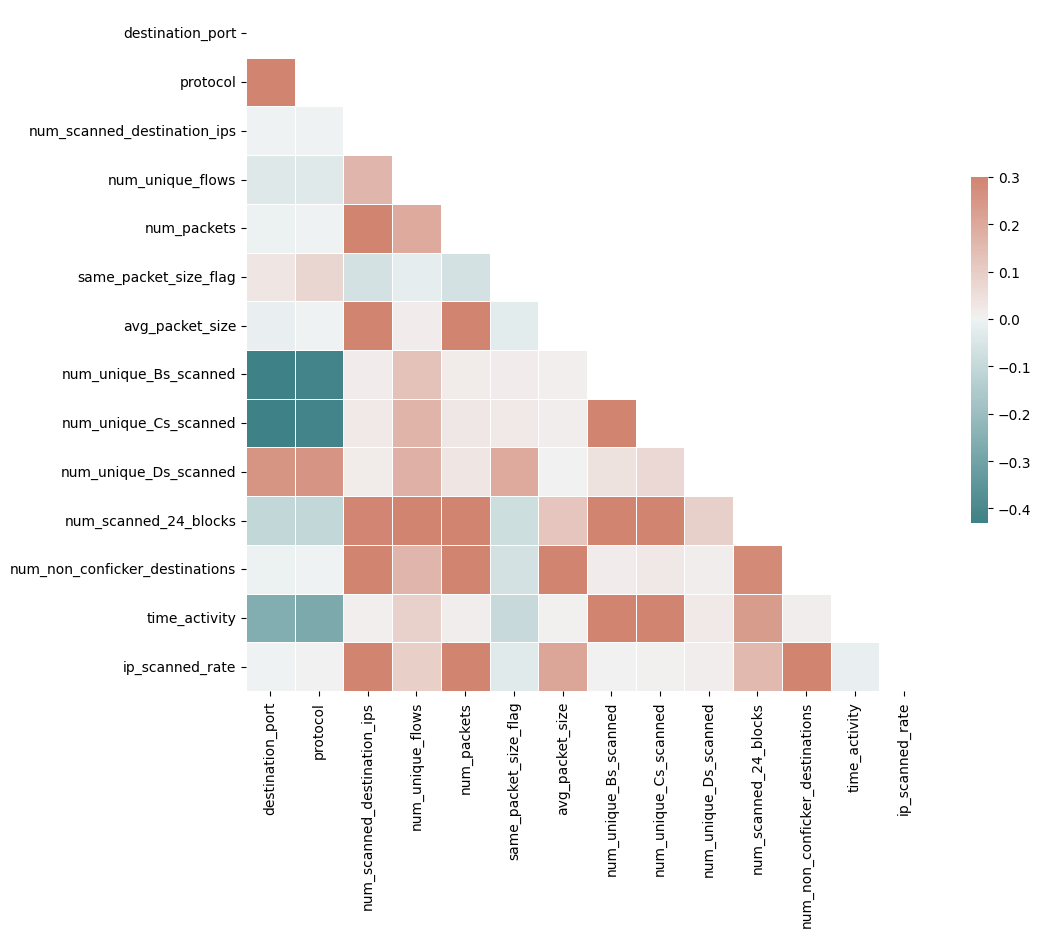

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

feat_df = df.drop(columns=['int_source_ip']) # keep compromised to see corr
corr = feat_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

f, ax = plt.subplots(figsize=(11, 9))

cmap = sns.diverging_palette(200, 20, as_cmap=True)

sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

plt.show()

Observations:
- Protocol and Destination port has a positive correlation

# Output CSV

In [51]:
import datetime
for df, dt in zip(hourly_df, hourly_timestamps):
  dt = datetime.datetime.strptime(dt, "%Y-%m-%d %H:%M:%S")
  dt = int(dt.timestamp())
  output_path = DATA_FOLDER / f"{dt}.csv"
  df.to_csv(output_path, index=False)